## ДЗ 3.
# Поиск гиперпараметров для модели.

**Цель**
* формирование практических навыков:
  
    - поиск гиперпараметров по схеме сеточного поиска
    - поиск гиперпараметров по схема случайного поиска
    - формирования отчета.

* **Задачи**:
    - выполнить загрузку всех составляющих данных,
    - определить список предикторов и целевой признак,
    - определить типы признаков и провести оценку их полноты,
    - оценить сбалансированность данных по целевому признаку,
    - Провести этап EDA - дз1,
    - Провести селекцию признаков оставить 50% признаков (лучшая моель ДЗ2).
    - Провести поиск гиперпараметров GridSearchCV, RandomizedSearchCV
    - по желанию использовать модель поиска hyperopt иил Optuna()
    - Провести анализ результатов
    - По результатам анализа сделать выводы о качестве решений.
    
* **Среда анализа** python-sklearn-scipy- hyperopt


In [ ]:


# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
import pandas as pd

import sklearn



## <center>Практическая часть<a class="anchor" id="practice"></a><center>

### 1. Выполнить загрузку всех составляющих данных


Требуется на основании демографических данных о клиентах банка, истории их платежей и состоянии счета, предсказать невыполнение их обязательств по кредитной карте в следующем месяце.

**Описание датасета**

* **Home Ownership** - домовладение
* **Annual Income** - годовой доход
* **Years in current job** - количество лет на текущем месте работы
* **Tax Liens** - налоговые обременения
* **Number of Open Accounts** - количество открытых счетов
* **Years of Credit History** - количество лет кредитной истории
* **Maximum Open Credit** - наибольший открытый кредит
* **Number of Credit Problems** - количество проблем с кредитом
* **Months since last delinquent** - количество месяцев с последней просрочки платежа
* **Bankruptcies** - банкротства
* **Purpose** - цель кредита
* **Term** - срок кредита
* **Current Loan Amount** - текущая сумма кредита
* **Current Credit Balance** - текущий кредитный баланс
* **Monthly Debt** - ежемесячный долг
* **Credit Default** - факт невыполнения кредитных обязательств (0 - погашен вовремя, 1 - просрочка)

- - -

**Подключение библиотек и скриптов**

In [ ]:
import numpy as np
import pandas as pd

**Пути к директориям и файлам**

In [ ]:
# input

DATASET_PATH = 'course_project_train.csv'

# output
PREP_DATASET_PATH = 'training_project_data_prep.csv'

### Загрузка данных<a class="anchor" id="load_data"></a>

In [ ]:
df = pd.read_csv(DATASET_PATH)
df.head()

,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


### 2. Определить список предикторов и целевой признак,

In [ ]:
df.shape

(7500, 17)

In [ ]:
df.iloc[0]

,0
Home Ownership,Own Home
Annual Income,482087.0
Years in current job,NaN
Tax Liens,0.0
Number of Open Accounts,11.0
Years of Credit History,26.3
Maximum Open Credit,685960.0
Number of Credit Problems,1.0
Months since last delinquent,NaN
Bankruptcies,1.0


**Целевой признак**: Credit Default


**Предикторы**:

In [ ]:
df.columns[:-1]

Index(['Home Ownership', 'Annual Income', 'Years in current job', 'Tax Liens',
       'Number of Open Accounts', 'Years of Credit History',
       'Maximum Open Credit', 'Number of Credit Problems',
       'Months since last delinquent', 'Bankruptcies', 'Purpose', 'Term',
       'Current Loan Amount', 'Current Credit Balance', 'Monthly Debt',
       'Credit Score'],
      dtype='object')

### 3. Определить типы признаков и провести оценку их полноты

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Home Ownership                7500 non-null   object 
 1   Annual Income                 5943 non-null   float64
 2   Years in current job          7129 non-null   object 
 3   Tax Liens                     7500 non-null   float64
 4   Number of Open Accounts       7500 non-null   float64
 5   Years of Credit History       7500 non-null   float64
 6   Maximum Open Credit           7500 non-null   float64
 7   Number of Credit Problems     7500 non-null   float64
 8   Months since last delinquent  3419 non-null   float64
 9   Bankruptcies                  7486 non-null   float64
 10  Purpose                       7500 non-null   object 
 11  Term                          7500 non-null   object 
 12  Current Loan Amount           7500 non-null   float64
 13  Cur

### Определить по числу значений признаков число пропусков: пропусков нет

In [ ]:
rez = pd.DataFrame(data = np.zeros(len(df.columns)).reshape(-1,1),index =df.columns,columns =['пропусков'])
for name_ in df.columns:
    n_ = df[name_].isnull().sum()
    rez.loc[name_,['пропусков']] = n_
    if (n_)>0:
        print('в признаке', name_,' обнаружено ', n_, ' пропусков')
    else:
        print('в признаке', name_,' обнаружено 0 пропусков')

в признаке Home Ownership  обнаружено 0 пропусков
в признаке Annual Income  обнаружено  1557  пропусков
в признаке Years in current job  обнаружено  371  пропусков
в признаке Tax Liens  обнаружено 0 пропусков
в признаке Number of Open Accounts  обнаружено 0 пропусков
в признаке Years of Credit History  обнаружено 0 пропусков
в признаке Maximum Open Credit  обнаружено 0 пропусков
в признаке Number of Credit Problems  обнаружено 0 пропусков
в признаке Months since last delinquent  обнаружено  4081  пропусков
в признаке Bankruptcies  обнаружено  14  пропусков
в признаке Purpose  обнаружено 0 пропусков
в признаке Term  обнаружено 0 пропусков
в признаке Current Loan Amount  обнаружено 0 пропусков
в признаке Current Credit Balance  обнаружено 0 пропусков
в признаке Monthly Debt  обнаружено 0 пропусков
в признаке Credit Score  обнаружено  1557  пропусков
в признаке Credit Default  обнаружено 0 пропусков


**Вывод**: Пропуски в признаках

In [ ]:
rez

,пропусков
Home Ownership,0.0
Annual Income,1557.0
Years in current job,371.0
Tax Liens,0.0
Number of Open Accounts,0.0
Years of Credit History,0.0
Maximum Open Credit,0.0
Number of Credit Problems,0.0
Months since last delinquent,4081.0
Bankruptcies,14.0


### Приведение типов<a class="anchor" id="cast"></a>

Сделаем все не числовые типы строками

In [ ]:
for colname in ['Years in current job', 'Home Ownership', 'Purpose', 'Term']:
    df[colname] = df[colname].astype(str)

In [ ]:
df.dtypes

,0
Home Ownership,object
Annual Income,float64
Years in current job,object
Tax Liens,float64
Number of Open Accounts,float64
Years of Credit History,float64
Maximum Open Credit,float64
Number of Credit Problems,float64
Months since last delinquent,float64
Bankruptcies,float64


In [ ]:
rez['тип'] =''
for name_ in df.columns:
    rez.loc[name_,'тип'] = df[name_].dtype
rez

,пропусков,тип
Home Ownership,0.0,object
Annual Income,1557.0,float64
Years in current job,371.0,object
Tax Liens,0.0,float64
Number of Open Accounts,0.0,float64
Years of Credit History,0.0,float64
Maximum Open Credit,0.0,float64
Number of Credit Problems,0.0,float64
Months since last delinquent,4081.0,float64
Bankruptcies,14.0,float64


**Результат**: Все признаки числового или строкового типа

### 4. Оценить сбалансированность данных по целевому признаку
#### Обзор данных<a class="anchor" id="review"></a>

**Обзор целевой переменной**

In [ ]:
target = 'Credit Default'
df['Credit Default'].value_counts()


,count
Credit Default,
0,5387
1,2113


**Вывод**: Выборка сильно разбалансирована.

**Обзор количественных признаков**

In [ ]:
d_df = df.describe()
num_col = d_df.columns[:-1]
d_df

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
count,5.943000e+03,7500.000000,7500.000000,7500.000000,7.500000e+03,7500.000000,3419.000000,7486.000000,7.500000e+03,7.500000e+03,7500.000000,5943.000000,7500.000000
mean,1.366392e+06,0.030133,11.130933,18.317467,9.451537e+05,0.170000,34.692600,0.117152,1.187318e+07,2.898332e+05,18314.454133,1151.087498,0.281733
std,8.453392e+05,0.271604,4.908924,7.041946,1.602622e+07,0.498598,21.688806,0.347192,3.192612e+07,3.178714e+05,11926.764673,1604.451418,0.449874
min,1.645970e+05,0.000000,2.000000,4.000000,0.000000e+00,0.000000,0.000000,0.000000,1.124200e+04,0.000000e+00,0.000000,585.000000,0.000000
25%,8.443410e+05,0.000000,8.000000,13.500000,2.792295e+05,0.000000,16.000000,0.000000,1.801690e+05,1.142565e+05,10067.500000,711.000000,0.000000
50%,1.168386e+06,0.000000,10.000000,17.000000,4.781590e+05,0.000000,32.000000,0.000000,3.095730e+05,2.093230e+05,16076.500000,731.000000,0.000000
75%,1.640137e+06,0.000000,14.000000,21.800000,7.935015e+05,0.000000,50.000000,0.000000,5.198820e+05,3.604062e+05,23818.000000,743.000000,1.000000
max,1.014934e+07,7.000000,43.000000,57.700000,1.304726e+09,7.000000,118.000000,4.000000,1.000000e+08,6.506797e+06,136679.000000,7510.000000,1.000000


In [ ]:
rez['moda'] = -1
rez['median'] = 0
rez['max'] = 0
rez['min'] = 0
rez['unique'] = -1
rez['std'] = 0

rez.loc[d_df.columns,'std'] = d_df.loc['std',:].values.T
rez.loc[d_df.columns,'max'] = d_df.loc['max',:].values.T
rez.loc[d_df.columns,'min'] = d_df.loc['min',:].values.T
rez.loc[d_df.columns,'median'] = d_df.loc['50%',:].values.T
rez

<ipython-input-15-b2a6d0c7cc75>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.45339200e+05 2.71603543e-01 4.90892413e+00 7.04194576e+00
 1.60262167e+07 4.98597847e-01 2.16888060e+01 3.47191746e-01
 3.19261230e+07 3.17871382e+05 1.19267647e+04 1.60445142e+03
 4.49874035e-01]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rez.loc[d_df.columns,'std'] = d_df.loc['std',:].values.T
<ipython-input-15-b2a6d0c7cc75>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.01493440e+07 7.00000000e+00 4.30000000e+01 5.77000000e+01
 1.30472617e+09 7.00000000e+00 1.18000000e+02 4.00000000e+00
 9.99999990e+07 6.50679700e+06 1.36679000e+05 7.51000000e+03
 1.00000000e+00]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rez.loc[d_df.columns,'max'] = d_df.

,пропусков,тип,moda,median,max,min,unique,std
Home Ownership,0.0,object,-1,0.0,0.000000e+00,0,-1,0.000000e+00
Annual Income,1557.0,float64,-1,1168386.0,1.014934e+07,164597,-1,8.453392e+05
Years in current job,371.0,object,-1,0.0,0.000000e+00,0,-1,0.000000e+00
Tax Liens,0.0,float64,-1,0.0,7.000000e+00,0,-1,2.716035e-01
Number of Open Accounts,0.0,float64,-1,10.0,4.300000e+01,2,-1,4.908924e+00
Years of Credit History,0.0,float64,-1,17.0,5.770000e+01,4,-1,7.041946e+00
Maximum Open Credit,0.0,float64,-1,478159.0,1.304726e+09,0,-1,1.602622e+07
Number of Credit Problems,0.0,float64,-1,0.0,7.000000e+00,0,-1,4.985978e-01
Months since last delinquent,4081.0,float64,-1,32.0,1.180000e+02,0,-1,2.168881e+01
Bankruptcies,14.0,float64,-1,0.0,4.000000e+00,0,-1,3.471917e-01


In [ ]:
n_col = df.select_dtypes(include='object').columns
n_col

Index(['Home Ownership', 'Years in current job', 'Purpose', 'Term'], dtype='object')

**Обзор номинативных признаков**

In [ ]:


for i,cat_colname in enumerate(n_col):
    c_df = df[cat_colname].value_counts()

    rez.loc[cat_colname,['unique','moda','max','min','std']] = [c_df.shape[0],c_df.index[0],c_df[0],c_df[-1],c_df.std()]
    print(str(cat_colname) + '\n\n' + str(c_df) + '\n' + '*' * 100 + '\n')
rez

Home Ownership

Home Ownership
Home Mortgage    3637
Rent             3204
Own Home          647
Have Mortgage      12
Name: count, dtype: int64
****************************************************************************************************

Years in current job

Years in current job
10+ years    2332
2 years       705
3 years       620
< 1 year      563
5 years       516
1 year        504
4 years       469
6 years       426
7 years       396
nan           371
8 years       339
9 years       259
Name: count, dtype: int64
****************************************************************************************************

Purpose

Purpose
debt consolidation      5944
other                    665
home improvements        412
business loan            129
buy a car                 96
medical bills             71
major purchase            40
take a trip               37
buy house                 34
small business            26
wedding                   15
moving                    11
e

<ipython-input-17-8ca2fc305ad0>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rez.loc[cat_colname,['unique','moda','max','min','std']] = [c_df.shape[0],c_df.index[0],c_df[0],c_df[-1],c_df.std()]
<ipython-input-17-8ca2fc305ad0>:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Home Mortgage' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rez.loc[cat_colname,['unique','moda','max','min','std']] = [c_df.shape[0],c_df.index[0],c_df[0],c_df[-1],c_df.std()]
<ipython-input-17-8ca2fc305ad0>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a v

,пропусков,тип,moda,median,max,min,unique,std
Home Ownership,0.0,object,Home Mortgage,0.0,3.637000e+03,12,4,1.811964e+03
Annual Income,1557.0,float64,-1,1168386.0,1.014934e+07,164597,-1,8.453392e+05
Years in current job,371.0,object,10+ years,0.0,2.332000e+03,259,12,5.516328e+02
Tax Liens,0.0,float64,-1,0.0,7.000000e+00,0,-1,2.716035e-01
Number of Open Accounts,0.0,float64,-1,10.0,4.300000e+01,2,-1,4.908924e+00
Years of Credit History,0.0,float64,-1,17.0,5.770000e+01,4,-1,7.041946e+00
Maximum Open Credit,0.0,float64,-1,478159.0,1.304726e+09,0,-1,1.602622e+07
Number of Credit Problems,0.0,float64,-1,0.0,7.000000e+00,0,-1,4.985978e-01
Months since last delinquent,4081.0,float64,-1,32.0,1.180000e+02,0,-1,2.168881e+01
Bankruptcies,14.0,float64,-1,0.0,4.000000e+00,0,-1,3.471917e-01


**Выводы**:
    
    1) Term : 2 уникальных значения, разбалансирована (5556/1944) (Гипотеза для проверки : ничего не нужно делать)
    2) Purpose : 15 уникальных значений, большая разница по числу значений моды и минора, значения 1, 2, 3 и 4 составляют основную часть выборки (Гипотеза для проверки : оставшиеся значения, вероятно нужно распределить по ним)
    3) ....
    
    9) Home Ownership	  1tе и 2е  значения основная часть примеров (Гипотеза для проверки : оставшиеся значения, вероятно нужно распределить по ним или объединить в новое значение)
        

### 5. Определить класс задачи

**РЕщаем задачу классификации, т.к. целевлй признак имеет только 2 значения**

### 6. Провести очистку данных и операцию заполнения пробелов

### Обработка пропусков<a class="anchor" id="gaps"></a>

In [ ]:
rez['пропусков']

,пропусков
Home Ownership,0.0
Annual Income,1557.0
Years in current job,371.0
Tax Liens,0.0
Number of Open Accounts,0.0
Years of Credit History,0.0
Maximum Open Credit,0.0
Number of Credit Problems,0.0
Months since last delinquent,4081.0
Bankruptcies,14.0


In [ ]:
df['Annual Income'].fillna(df['Annual Income'].median(),inplace = True,)

<ipython-input-19-f4bc465e99d9>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Annual Income'].fillna(df['Annual Income'].median(),inplace = True,)


In [ ]:
df['Months since last delinquent'].fillna(df['Months since last delinquent'].median(),inplace = True,)

<ipython-input-20-dcb1f16bcd79>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Months since last delinquent'].fillna(df['Months since last delinquent'].median(),inplace = True,)


In [ ]:
df['Credit Score'].fillna(df['Credit Score'].median(),inplace = True,)

<ipython-input-21-243a2d62ff05>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit Score'].fillna(df['Credit Score'].median(),inplace = True,)


In [ ]:
df['Bankruptcies'].fillna(0,inplace = True,)

<ipython-input-22-fa3daff515c6>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Bankruptcies'].fillna(0,inplace = True,)


### Обработка выбросов<a class="anchor" id="outliers"></a>

In [ ]:
df[n_col].head()

,Home Ownership,Years in current job,Purpose,Term
0,Own Home,nan,debt consolidation,Short Term
1,Own Home,10+ years,debt consolidation,Long Term
2,Home Mortgage,8 years,debt consolidation,Short Term
3,Own Home,6 years,debt consolidation,Short Term
4,Rent,8 years,debt consolidation,Short Term


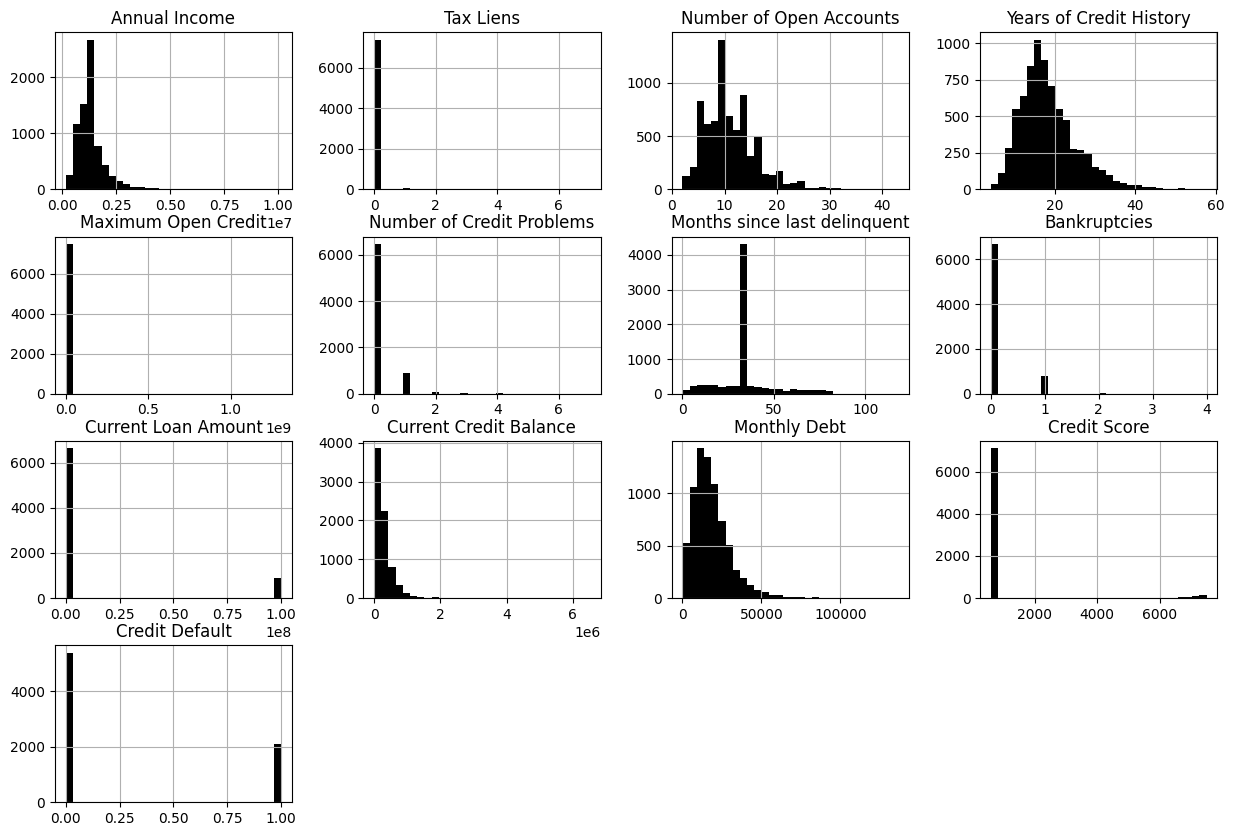

In [ ]:
df.hist(color="k", bins=30, figsize=(15, 10))
plt.show()


In [ ]:
from scipy import stats

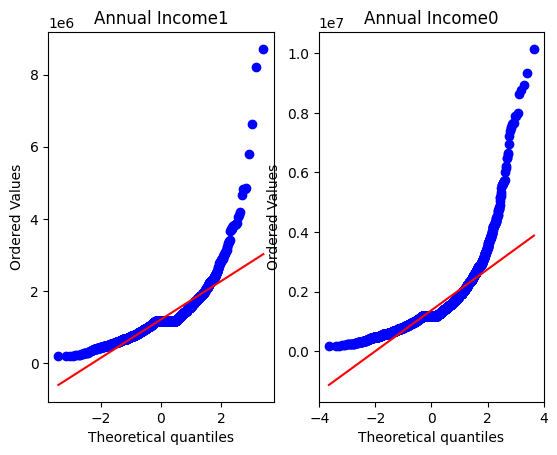

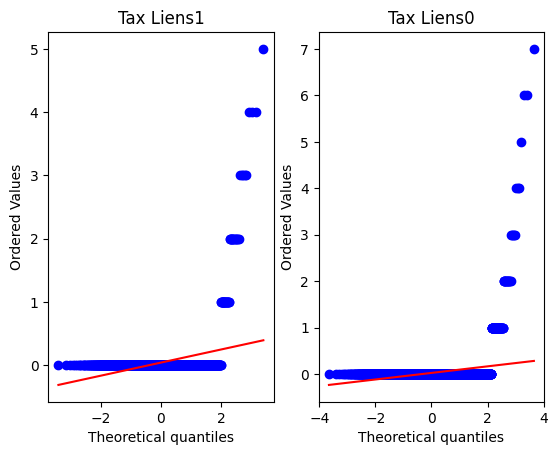

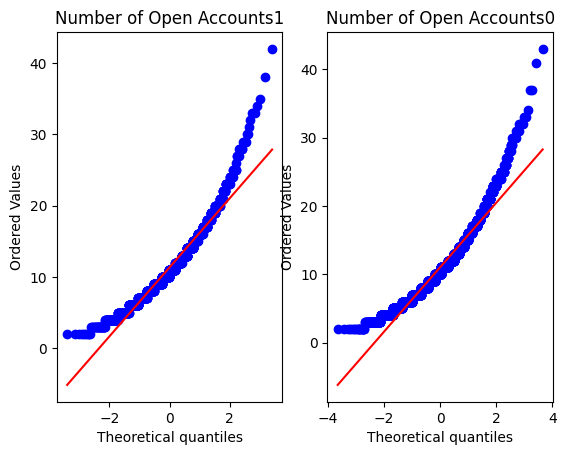

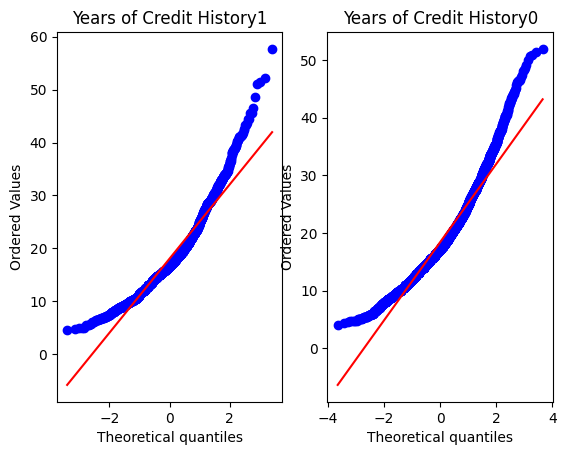

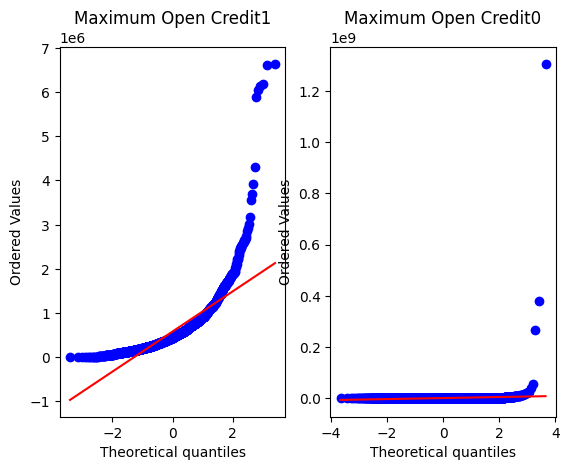

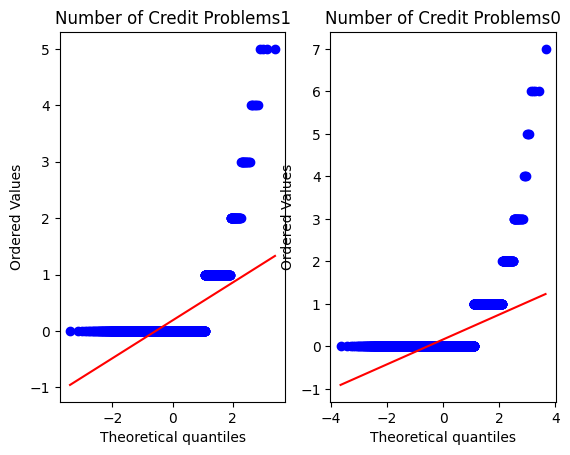

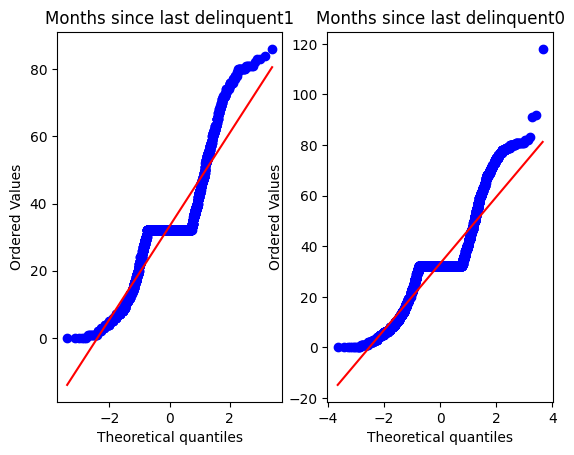

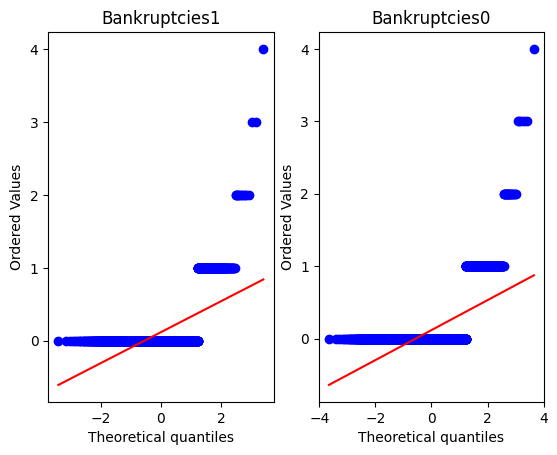

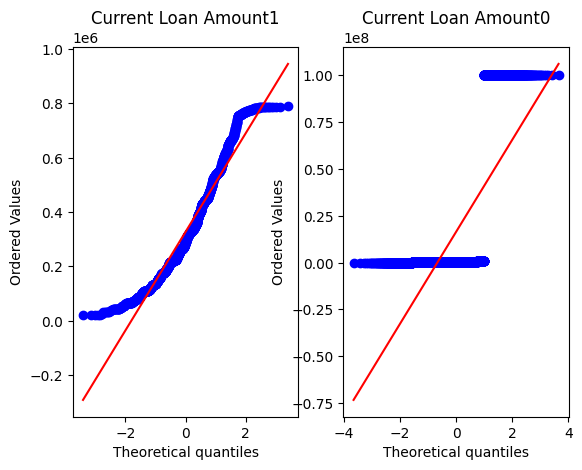

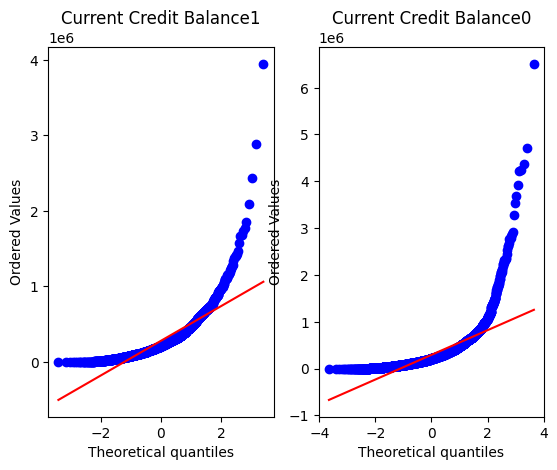

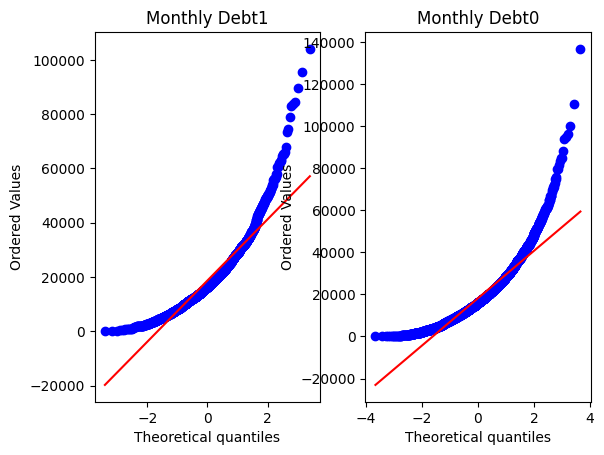

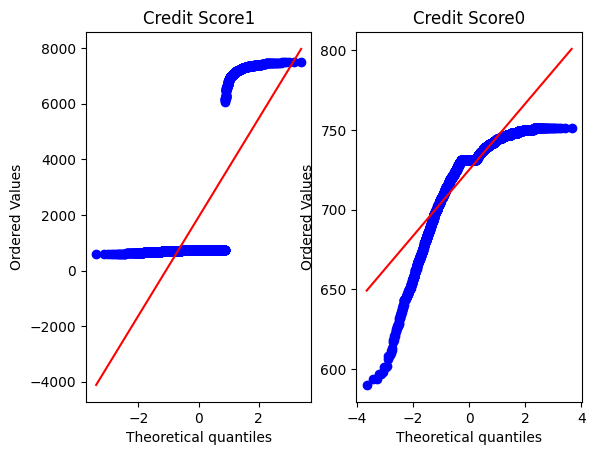

In [ ]:
for name_ in num_col:
    fig1, (ax1, ax2) = plt.subplots(1,2)

    p1 = stats.probplot(df.loc[df[target] == 1,name_ ], dist=stats.norm, plot=ax1)
    p2 = stats.probplot(df.loc[df[target] == 0,name_ ], dist=stats.norm, plot=ax2)

    ax1.set_title(name_ +'1')
    ax2.set_title(name_+'0')


Законы не нормальные

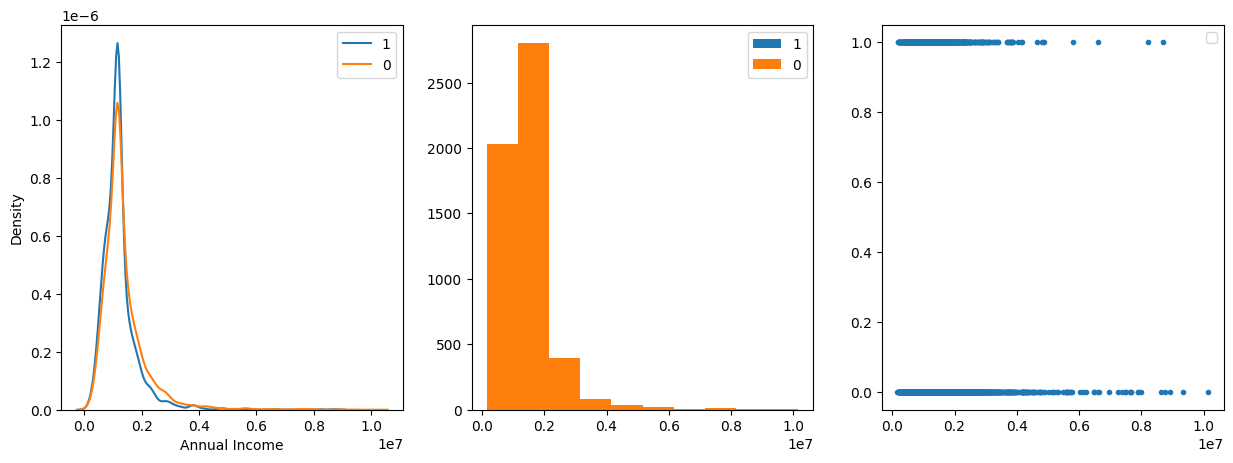

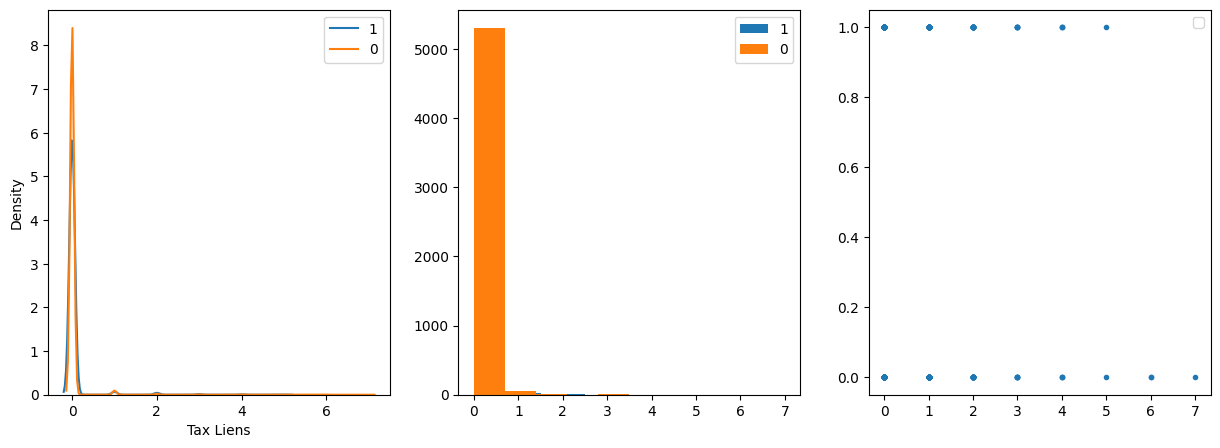

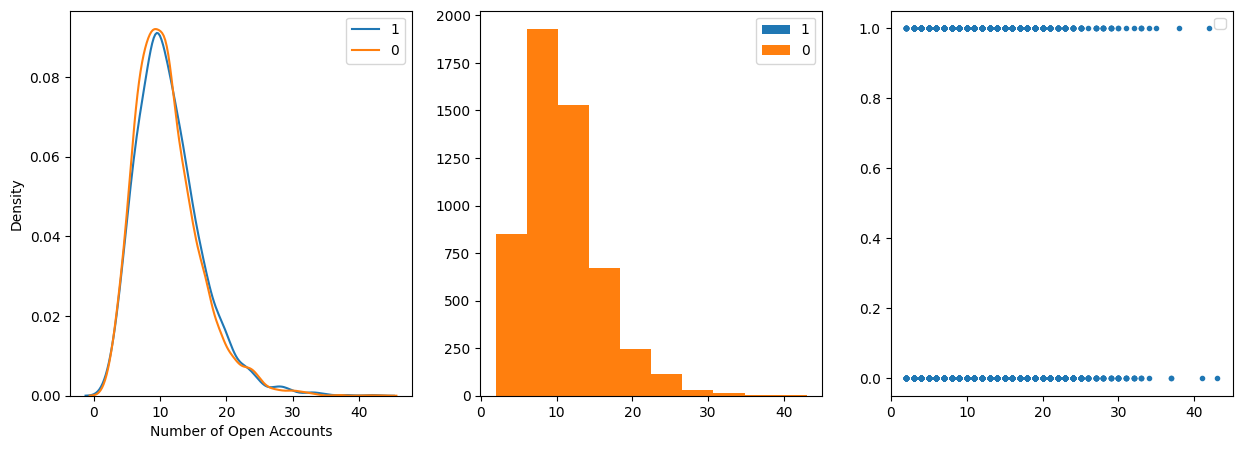

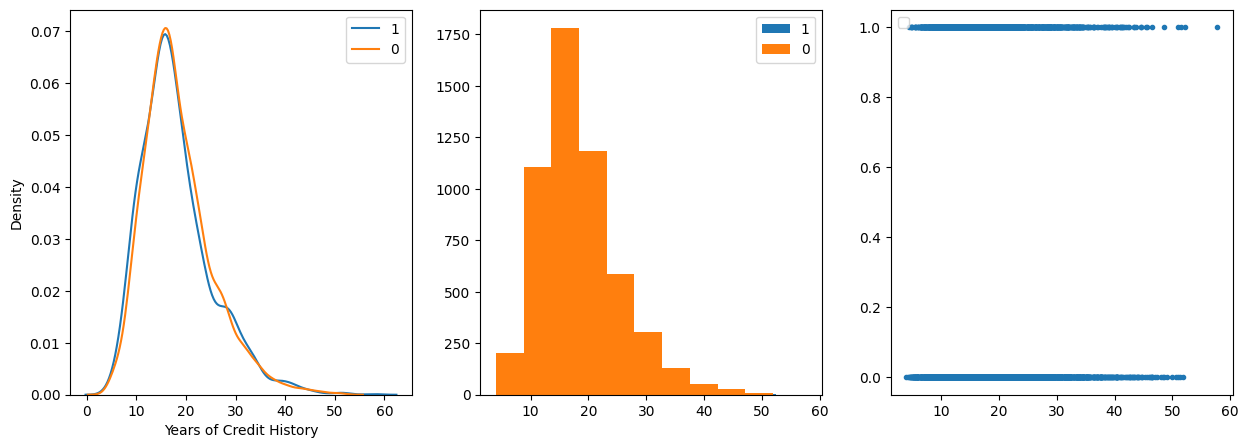

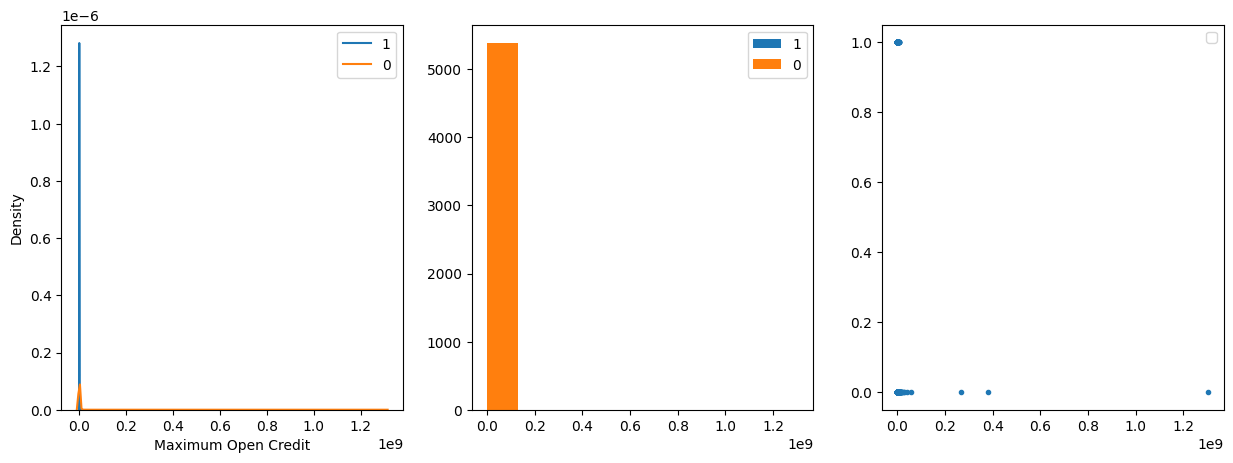

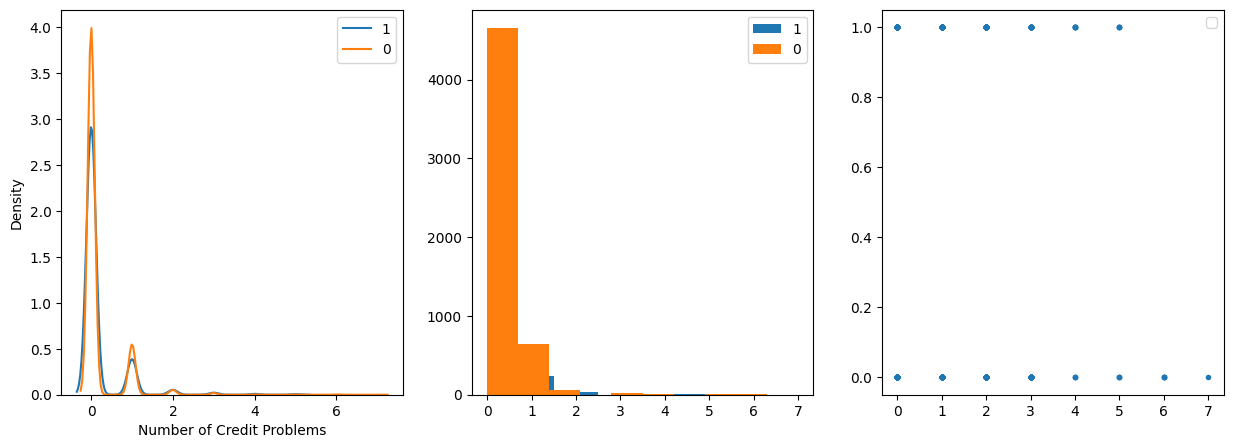

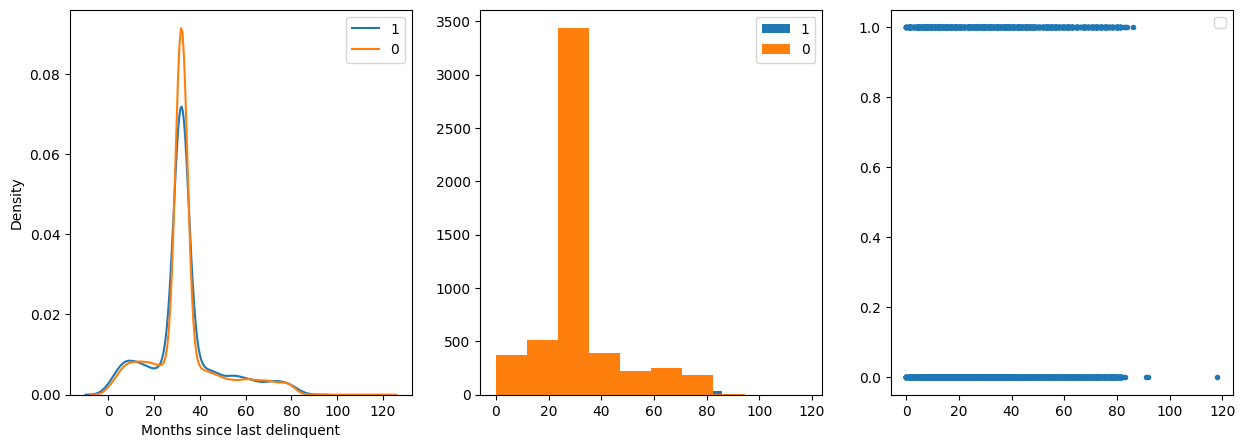

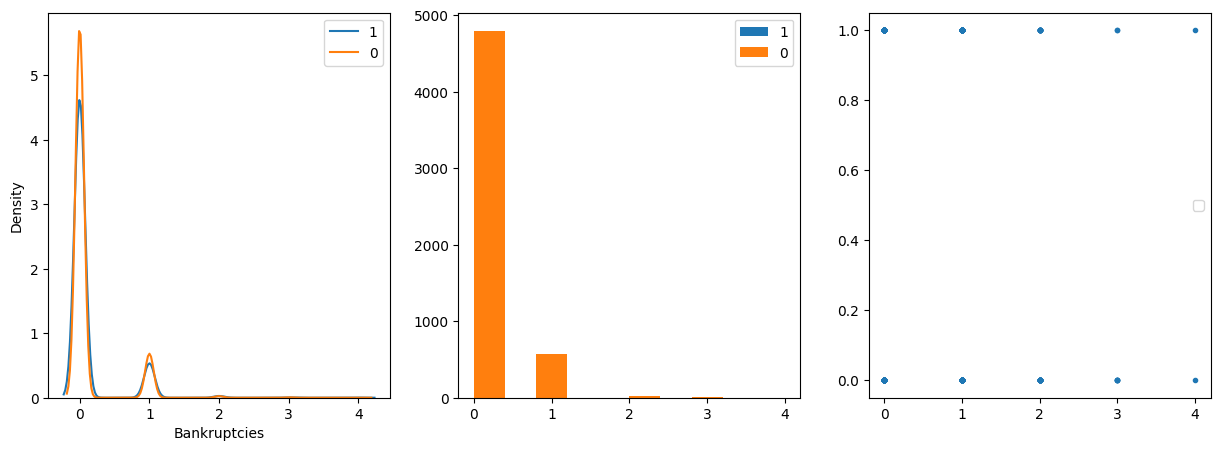

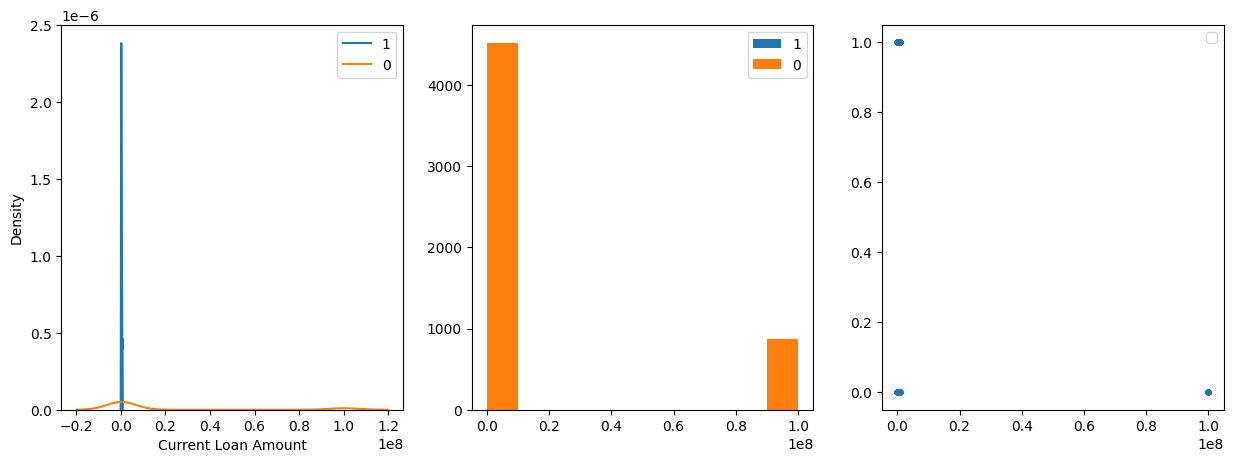

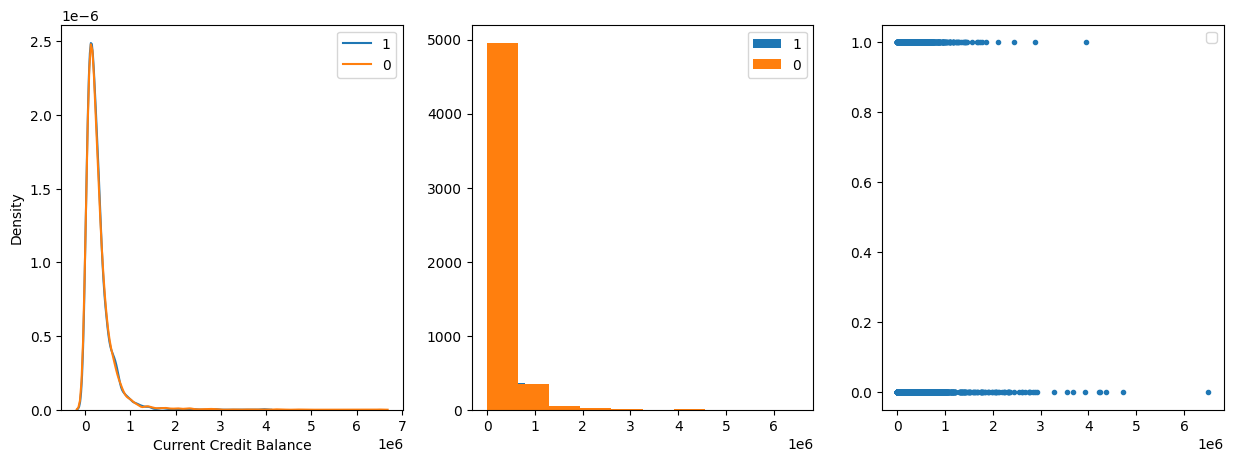

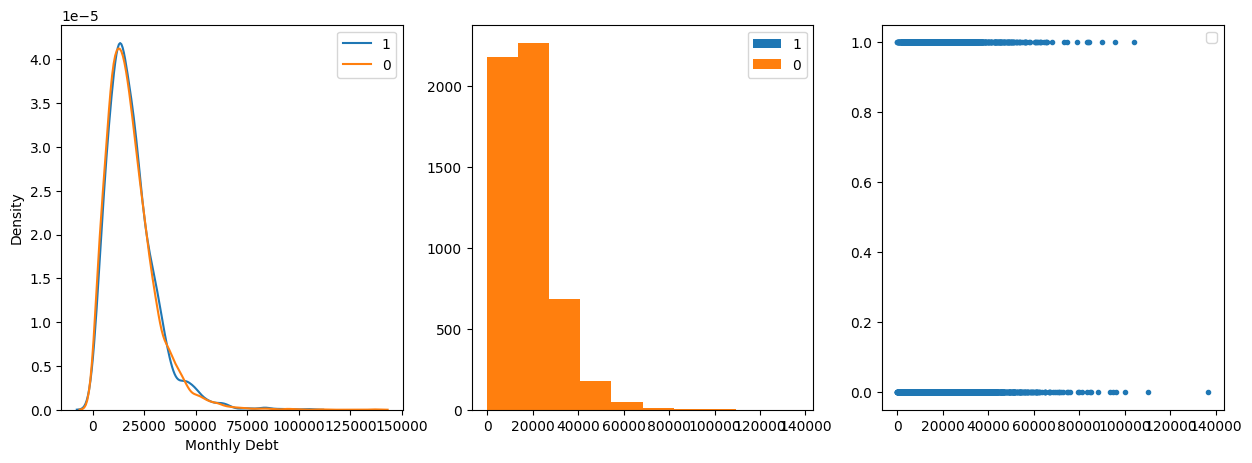

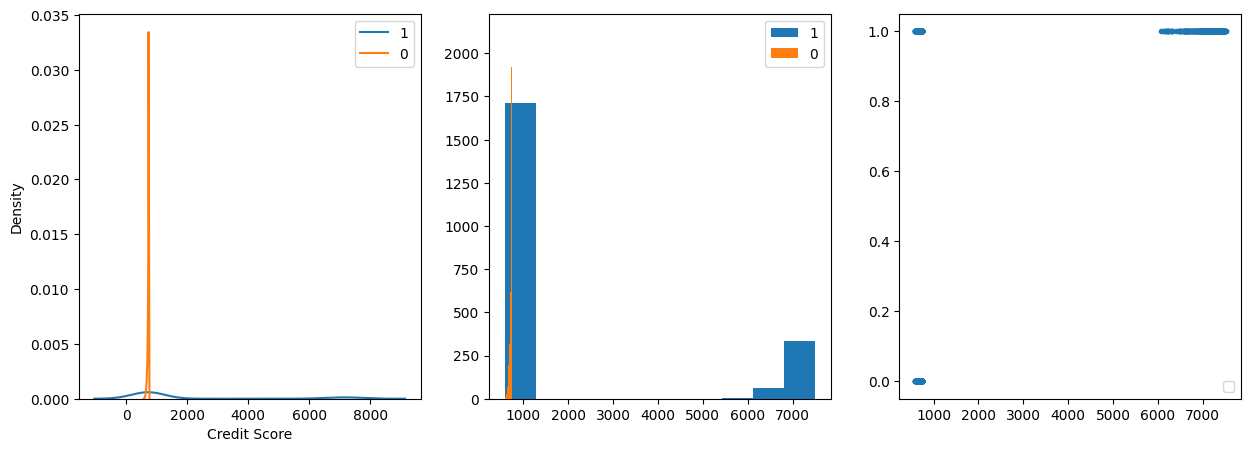

In [ ]:
for name_ in num_col:
  plt.figure(figsize = (15,5))

  plt.subplot(1,3,2)
  plt.hist(df.loc[df[target] == 1,name_ ],label = '1')
  plt.hist(df.loc[df[target] == 0,name_ ],label = '0')
  plt.legend()

  plt.subplot(1,3,3)
  plt.plot(df[name_ ],df[target],'.')

  plt.legend()

  plt.subplot(1,3,1)
  try:
        sns.kdeplot(df.loc[df[target] == 1,name_ ],label = '1')
        sns.kdeplot(df.loc[df[target] == 0,name_ ],label = '0')
        plt.legend()
  except:
        print('no kde')
  plt.show()


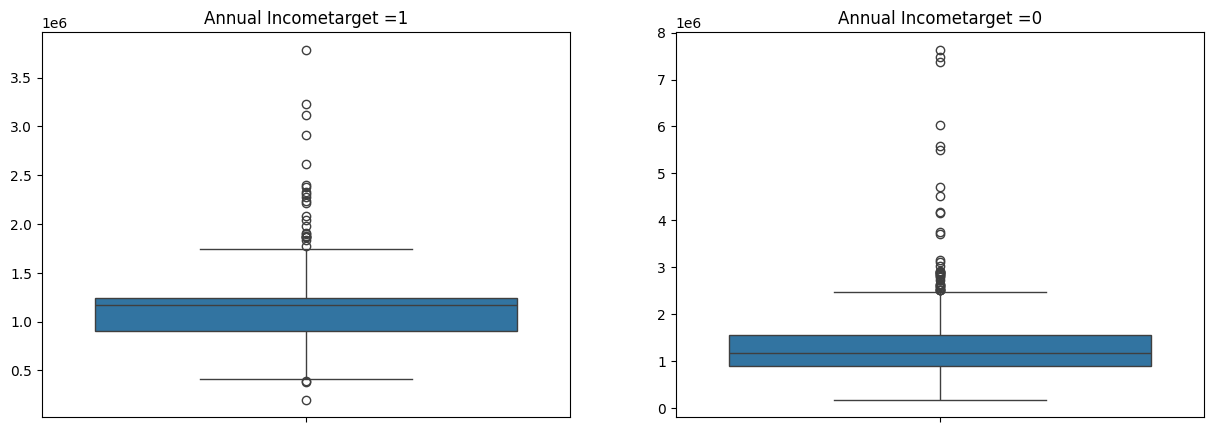

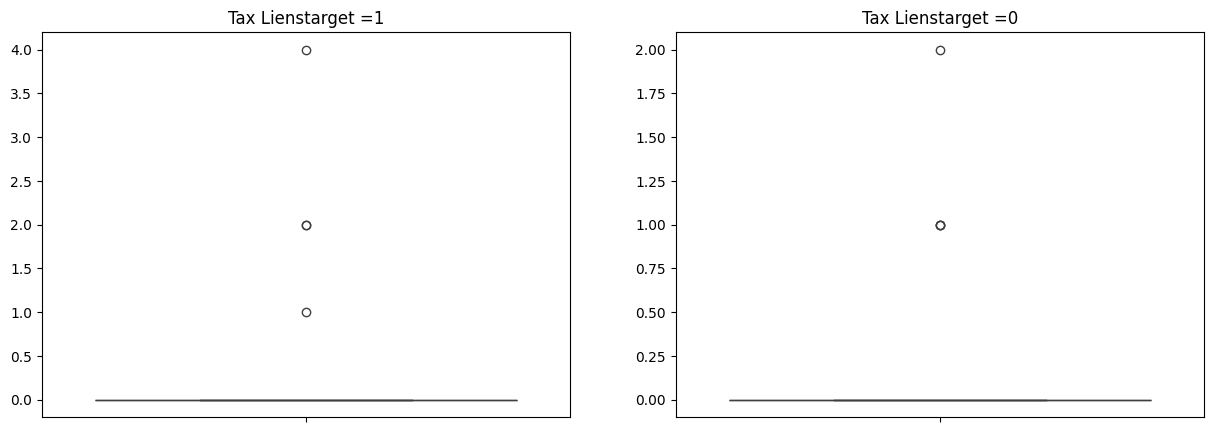

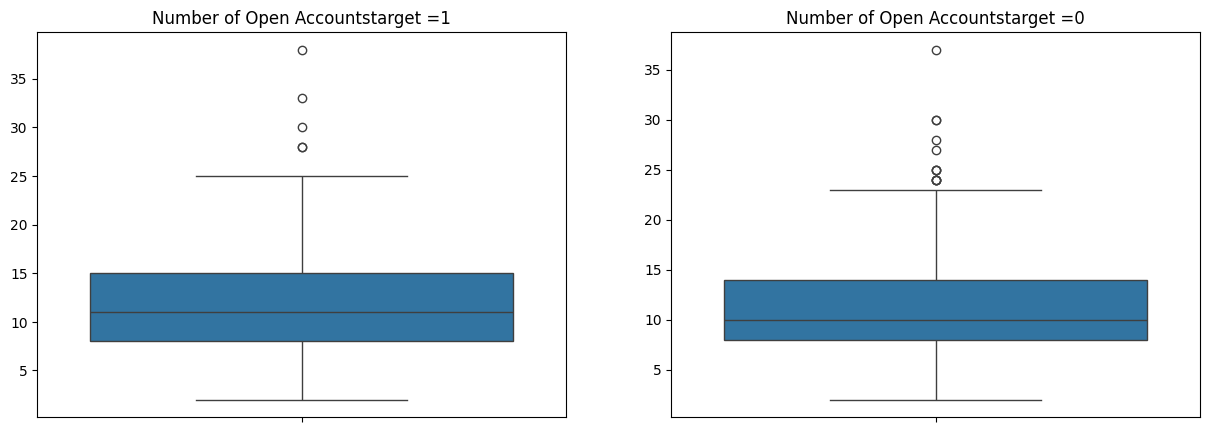

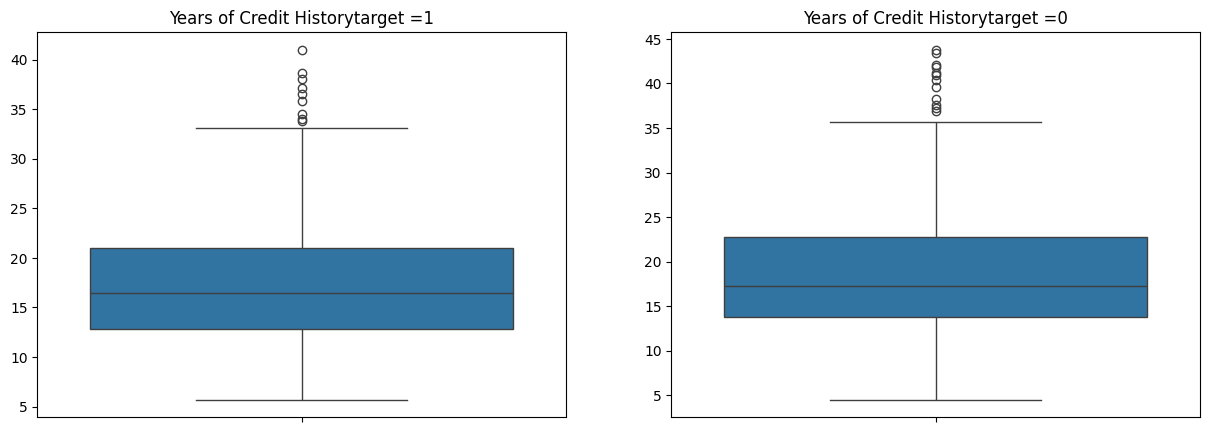

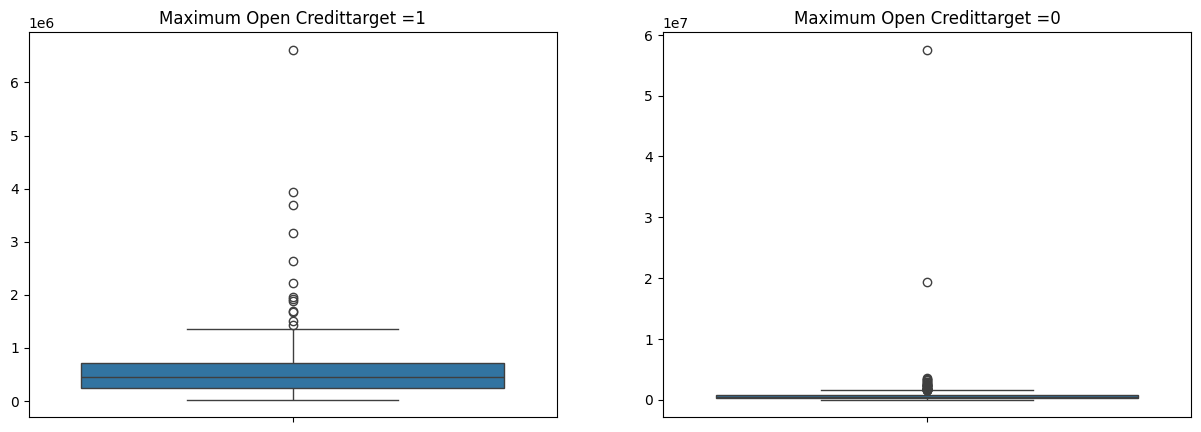

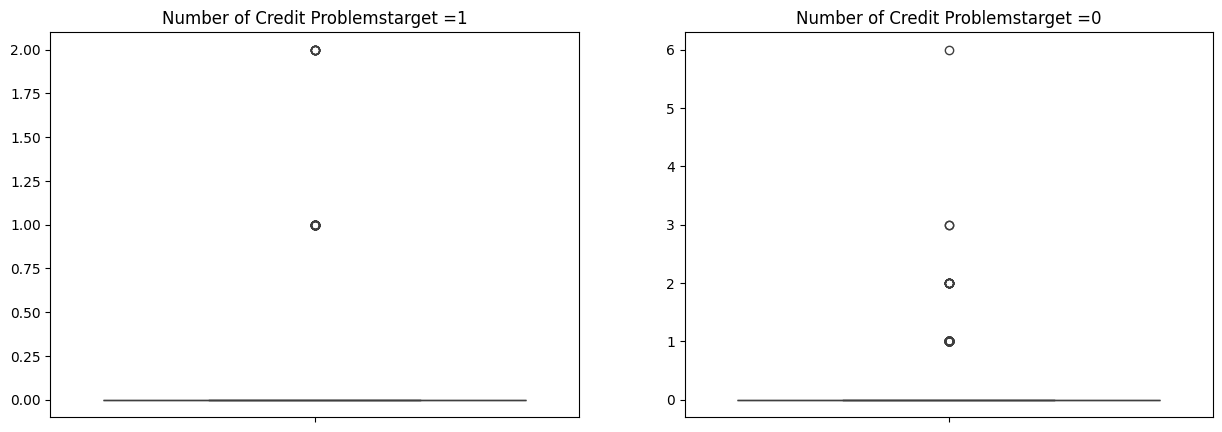

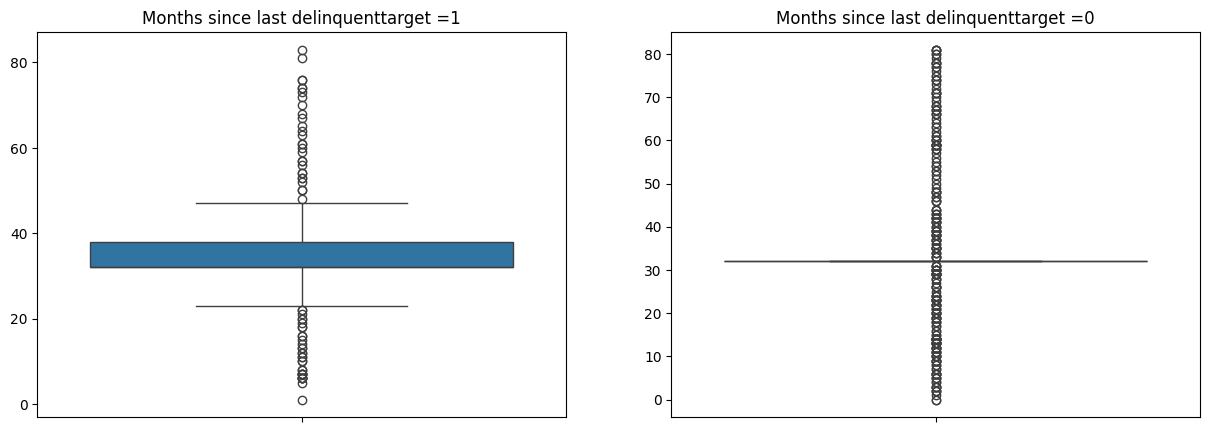

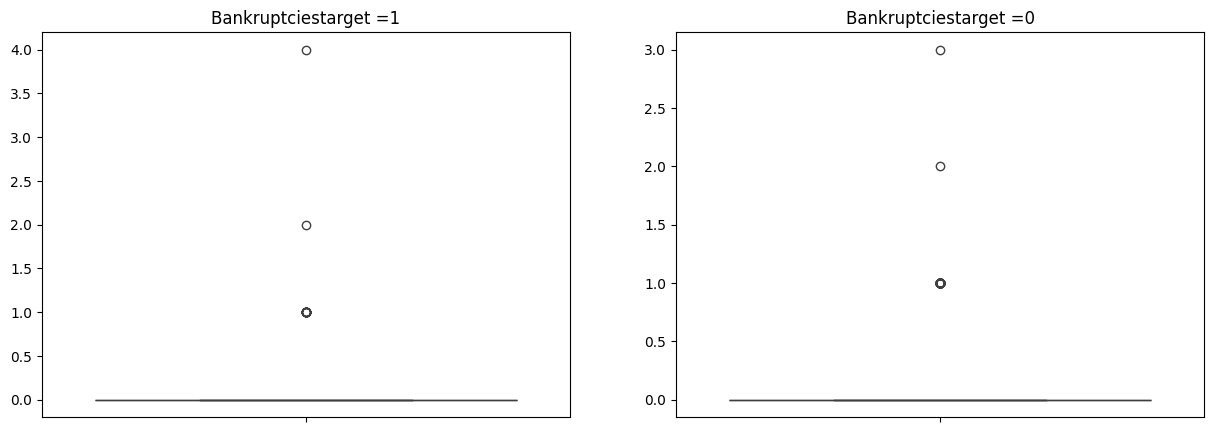

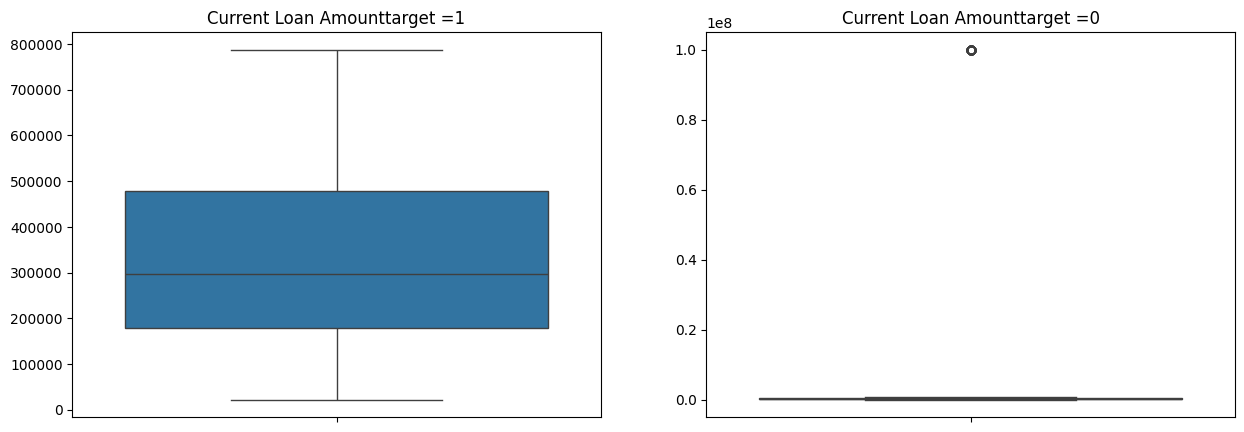

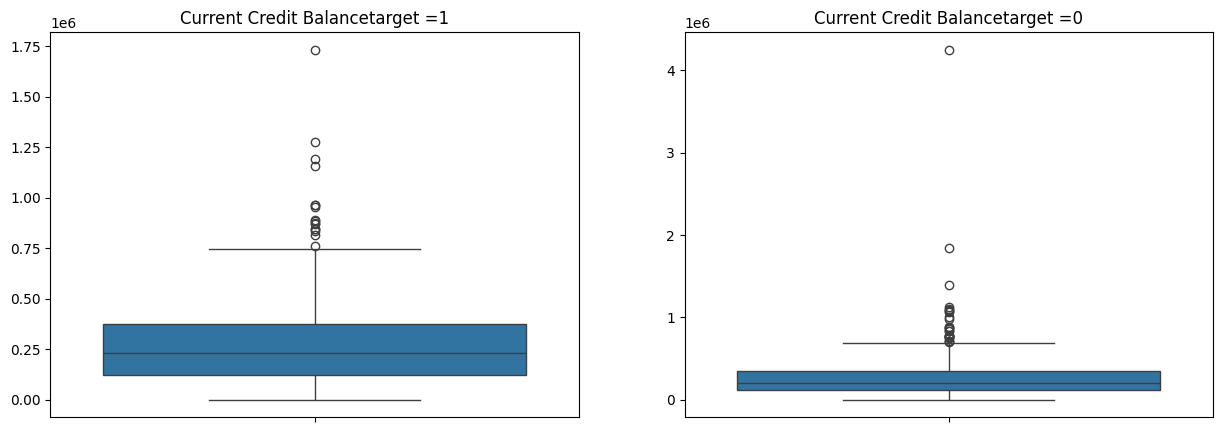

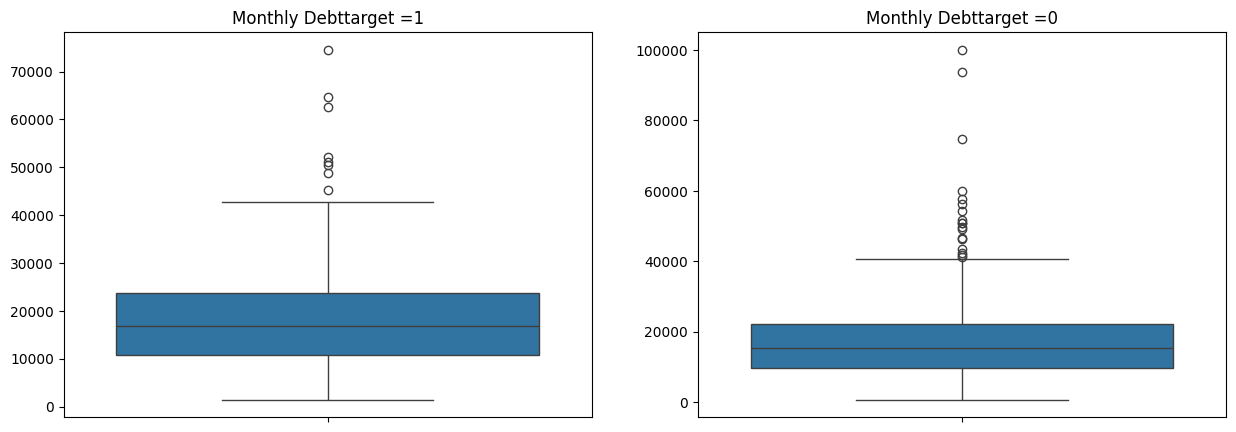

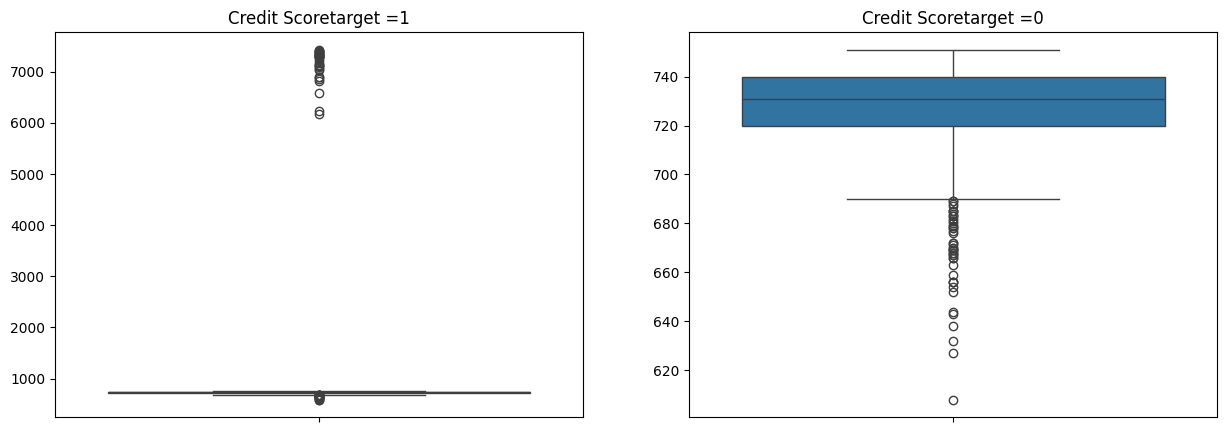

In [ ]:
for name_ in num_col:
    dfs = df.sample(frac=0.1)
    plt.figure(figsize = (15,5))
    plt.subplot(1,2,1)
    plt.title(name_+'target =1')
    sns.boxplot(dfs.loc[dfs[target]==1,name_ ].values)
    plt.subplot(1,2,2)
    sns.boxplot(dfs.loc[dfs[target]==0,name_ ].values)
    plt.title(name_+'target =0')
    plt.show()


**Вывод:**
    - Выбросы есть
    - закон распределения не нормальный (Гипотеза : провести нормализацию через логарифмические преобразования)

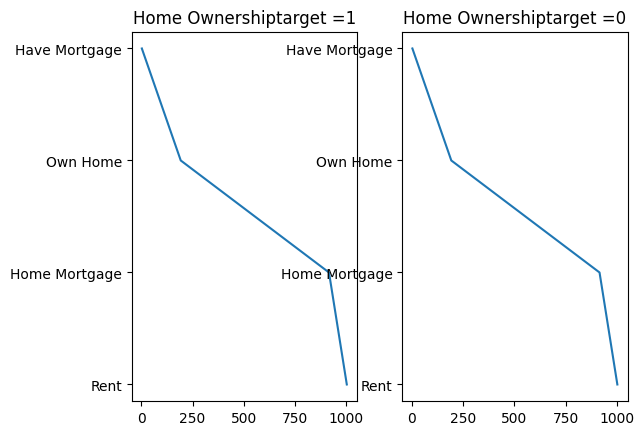

Home Ownership: 
 [[1003, 916, 192, 2], [1003, 916, 192, 2]]


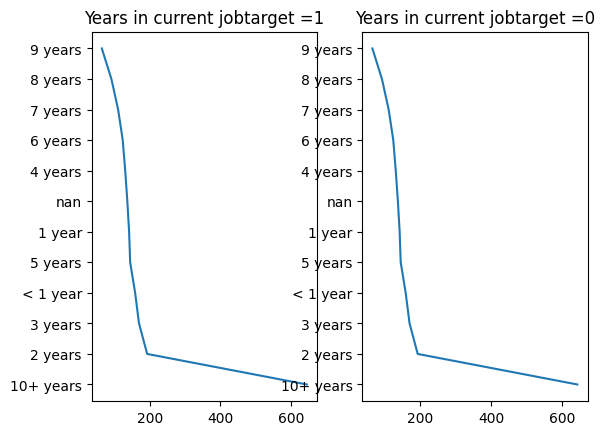

Years in current job: 
 [[644, 193, 170, 159, 145, 142, 137, 131, 124, 111, 92, 65], [644, 193, 170, 159, 145, 142, 137, 131, 124, 111, 92, 65]]


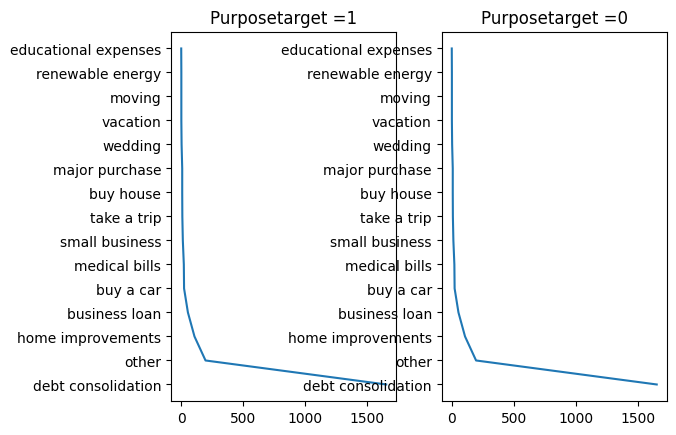

Purpose: 
 [[1654, 197, 108, 55, 24, 22, 14, 10, 9, 9, 4, 2, 2, 2, 1], [1654, 197, 108, 55, 24, 22, 14, 10, 9, 9, 4, 2, 2, 2, 1]]


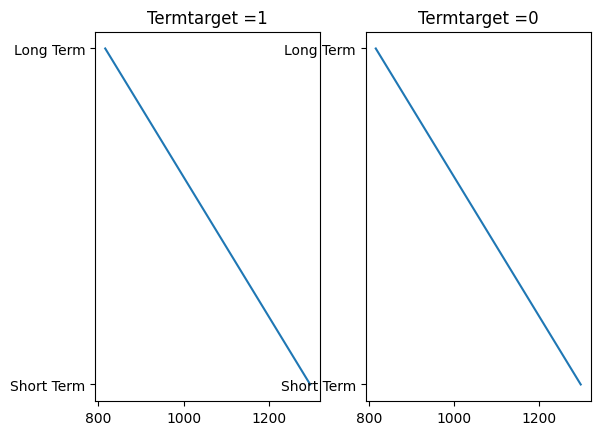

Term: 
 [[1297, 816], [1297, 816]]


In [ ]:

cat_hist ={}
for name_ in n_col:
    dfs = df.sample(frac=1)
    d1 = dfs.loc[dfs[target]==1,name_ ].value_counts()
    d0 = dfs.loc[dfs[target]==1,name_ ].value_counts()
    dn = [d1.values.T.tolist(),d0.values.T.tolist()]
    plt.subplot(1,2,1)
    plt.title(name_+'target =1')
    plt.plot(d1.values,d1.index)
    plt.subplot(1,2,2)
    plt.title(name_+'target =0')
    plt.plot(d0.values,d1.index)
    plt.show()
    cat_hist[name_]=dn
    print(name_+': \n',dn)

### 7. Селекция

Text(0.5, 1.0, 'Взаимные парные корреляции признаков')

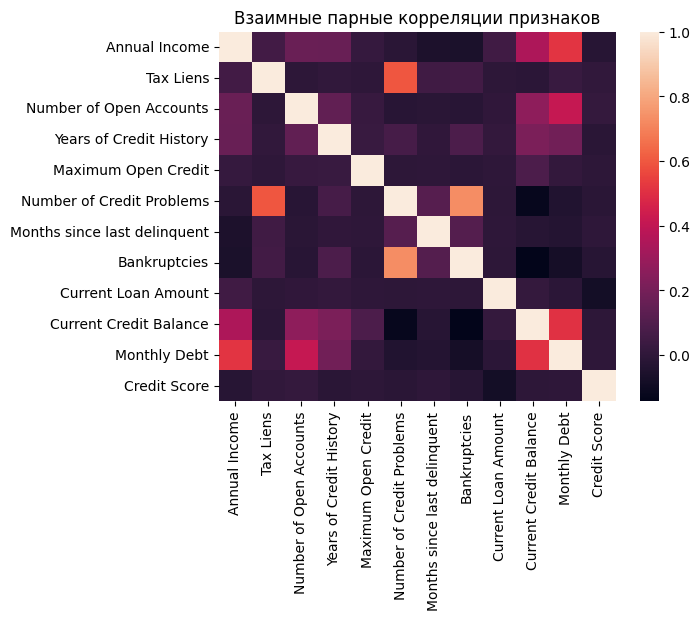

In [ ]:
# Взаимные парные корреляции признаков
cc=np.corrcoef(df.loc[:,num_col].values.T)

sns.heatmap(data=cc, xticklabels=df.loc[:,num_col].columns, yticklabels=df.loc[:,num_col].columns)
plt.title('Взаимные парные корреляции признаков')

Для вывода: ищем сс больше 0.7 - это мультиколлинеарность

In [ ]:
np.where(cc>0.7)

(array([ 0,  1,  2,  3,  4,  5,  5,  6,  7,  7,  8,  9, 10, 11]),
 array([ 0,  1,  2,  3,  4,  5,  7,  6,  5,  7,  8,  9, 10, 11]))

Все значения на диагонали, это сам с собой.

**Вывод**: мультиколлинеарных нет

Можно сделать стат.тесты для категорийных и численных признаков:
    - различимость распределений в разрезе целевой переменной (определит важность признака - чем различимей, тем лучше) -  ttest_rel
    - сходство частот (позволит уменьшить число категорий в признаке для номинальных) chi2_contingency

In [ ]:
from scipy.stats import shapiro, normaltest, ttest_rel, ttest_ind, kstest
from scipy.stats import ks_2samp, chi2_contingency

In [ ]:
df.head()

,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,nan,0.0,11.0,26.3,685960.0,1.0,32.0,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,32.0,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,32.0,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,32.0,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,32.0,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


In [ ]:
def cat_merge(X_,Y10,ID,FEATURE_NAME):
  '''
  Исследование на близость категорий по распределению
  Принимаем:
  X_, - твблица данных - pandas DataFrame
  Y10 - целевое свойство  - категорийного типа (непрерывное переводим на интервалы)
  ID, - номер уникальный , для подсчета объектов
  FEATURE_NAME - исследуемый признак

  Действие:
  вдоль целевого свойства смотрим на различимость распределений значений исследуемого признака
  по тесту Хи2

  Возвращаем
  CHI_ - значения p-value для пар значений признака в виде матрицы (строка/столбец - отдельные значения),
  numb_b
  '''
  print(ID,FEATURE_NAME)
  TARGET_NAME = 'Y10'
  X_[TARGET_NAME] = Y10
  b_max = len(X_[FEATURE_NAME].unique()) #  сколько категорий
  CHI_ = []
  numb_b ={}
  # смотрим на пары категорий
  for i_br in X_[FEATURE_NAME].unique():
    # сохраняем число примеров для этого значения по всем данным
    numb_b[str(i_br)] = X_.loc[X_[FEATURE_NAME].isin([i_br]), :].shape[0]
    for j_br in X_[FEATURE_NAME].unique():
      # выделили подтаблицу
      X_d = X_.loc[X_[FEATURE_NAME].isin([i_br, j_br]), [FEATURE_NAME, TARGET_NAME]]
      # выбираем число примеров для оценки в тесте Хи2
      if X_d.shape[0]>1000:
        n_samples = 1000
      else:
        n_samples = X_d.shape[0]
      # если значения есть, то оценим, иначе р=0
      if n_samples>0:
        rez_s = X_.loc[X_[FEATURE_NAME].isin([i_br, j_br]), [FEATURE_NAME, TARGET_NAME]].sample(n_samples)
        # частоты по значениям цели для значений признака
        rez_s[ID] = np.arange(rez_s.shape[0])
        table = rez_s.pivot_table(values=ID, index=TARGET_NAME, columns=FEATURE_NAME, aggfunc='count')+5
        table.fillna(5,inplace=True)
        chi2, p, dof, expected = chi2_contingency( table, correction=False)
      else:
        p = 0
      CHI_.append( p)
  CHI_ = np.array(CHI_).reshape((b_max,b_max))
  # чем белее, тем больше оснований для объединения значений
  sns.heatmap(data = CHI_, xticklabels=X_[FEATURE_NAME].unique(),yticklabels=X_[FEATURE_NAME].unique())
  print(numb_b)
  return CHI_,numb_b

ID Home Ownership
{'Own Home': 647, 'Home Mortgage': 3637, 'Rent': 3204, 'Have Mortgage': 12}


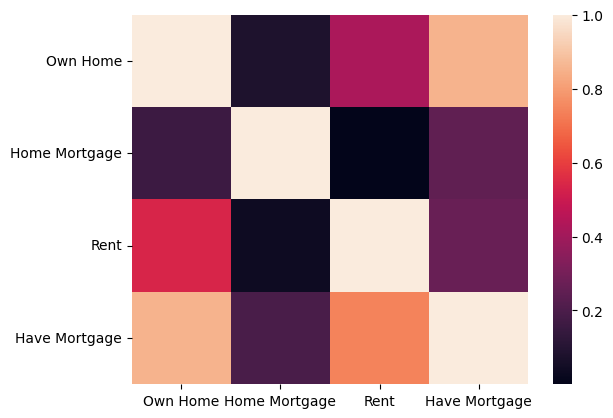

In [ ]:

chi_bed,numb_bed = cat_merge(df.loc[:,n_col[:1]],df[ target], 'ID',n_col[0])

Вывод: когеррентны own Home - Have Mortage - Rent

Сделаем категорийные признаки числовыми (pd.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False, dtype=None)):
    

In [ ]:
df = pd.get_dummies(df,columns = n_col, prefix=n_col, prefix_sep='_', dummy_na=True )

df.head()

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,...,Purpose_other,Purpose_renewable energy,Purpose_small business,Purpose_take a trip,Purpose_vacation,Purpose_wedding,Purpose_nan,Term_Long Term,Term_Short Term,Term_nan
0,482087.0,0.0,11.0,26.3,685960.0,1.0,32.0,1.0,99999999.0,47386.0,...,False,False,False,False,False,False,False,False,True,False
1,1025487.0,0.0,15.0,15.3,1181730.0,0.0,32.0,0.0,264968.0,394972.0,...,False,False,False,False,False,False,False,True,False,False
2,751412.0,0.0,11.0,35.0,1182434.0,0.0,32.0,0.0,99999999.0,308389.0,...,False,False,False,False,False,False,False,False,True,False
3,805068.0,0.0,8.0,22.5,147400.0,1.0,32.0,1.0,121396.0,95855.0,...,False,False,False,False,False,False,False,False,True,False
4,776264.0,0.0,13.0,13.6,385836.0,1.0,32.0,0.0,125840.0,93309.0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Annual Income                   7500 non-null   float64
 1   Tax Liens                       7500 non-null   float64
 2   Number of Open Accounts         7500 non-null   float64
 3   Years of Credit History         7500 non-null   float64
 4   Maximum Open Credit             7500 non-null   float64
 5   Number of Credit Problems       7500 non-null   float64
 6   Months since last delinquent    7500 non-null   float64
 7   Bankruptcies                    7500 non-null   float64
 8   Current Loan Amount             7500 non-null   float64
 9   Current Credit Balance          7500 non-null   float64
 10  Monthly Debt                    7500 non-null   float64
 11  Credit Score                    7500 non-null   float64
 12  Credit Default                  75

In [ ]:
col_del = ['Term_nan','Years in current job_nan','Home Ownership_Home Mortgage']
df.drop(col_del, axis=1, inplace=True)

In [ ]:
df

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,...,Purpose_moving,Purpose_other,Purpose_renewable energy,Purpose_small business,Purpose_take a trip,Purpose_vacation,Purpose_wedding,Purpose_nan,Term_Long Term,Term_Short Term
0,482087.0,0.0,11.0,26.3,685960.0,1.0,32.0,1.0,99999999.0,47386.0,...,False,False,False,False,False,False,False,False,False,True
1,1025487.0,0.0,15.0,15.3,1181730.0,0.0,32.0,0.0,264968.0,394972.0,...,False,False,False,False,False,False,False,False,True,False
2,751412.0,0.0,11.0,35.0,1182434.0,0.0,32.0,0.0,99999999.0,308389.0,...,False,False,False,False,False,False,False,False,False,True
3,805068.0,0.0,8.0,22.5,147400.0,1.0,32.0,1.0,121396.0,95855.0,...,False,False,False,False,False,False,False,False,False,True
4,776264.0,0.0,13.0,13.6,385836.0,1.0,32.0,0.0,125840.0,93309.0,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,402192.0,0.0,3.0,8.5,107866.0,0.0,32.0,0.0,129360.0,73492.0,...,False,True,False,False,False,False,False,False,False,True
7496,1533984.0,0.0,10.0,26.5,686312.0,0.0,43.0,0.0,444048.0,456399.0,...,False,False,False,False,False,False,False,False,True,False
7497,1878910.0,0.0,12.0,32.1,1778920.0,0.0,32.0,0.0,99999999.0,477812.0,...,False,False,False,False,False,False,False,False,False,True
7498,1168386.0,0.0,21.0,26.5,1141250.0,0.0,32.0,0.0,615274.0,476064.0,...,False,False,False,False,False,False,False,False,False,True


Text(0.5, 1.0, 'Взаимные парные корреляции признаков')

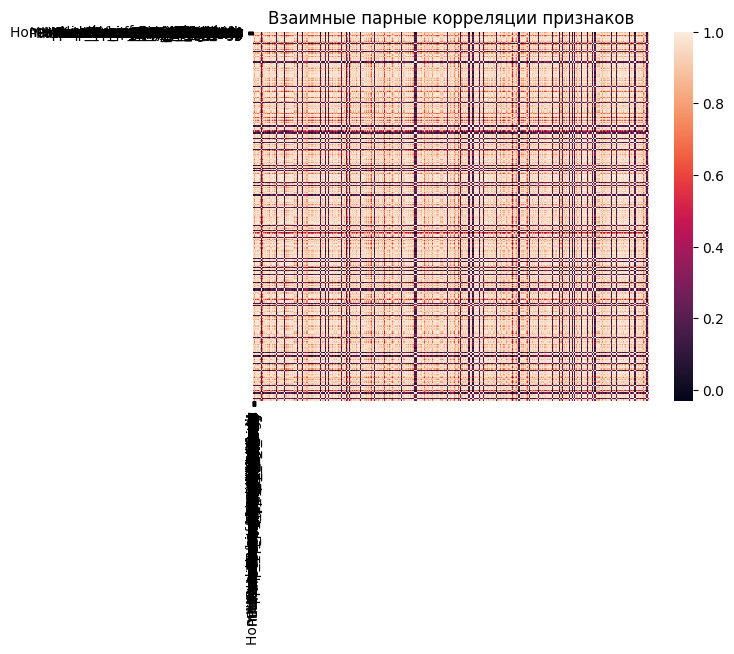

In [ ]:
# Взаимные парные корреляции всех признаков
cc=np.corrcoef(df.values.astype(np.float32))

sns.heatmap(data=cc, xticklabels=df.columns, yticklabels=df.columns)
plt.title('Взаимные парные корреляции признаков')

In [ ]:
p_c = np.where(cc>0.7)
for i in range(df.shape[1]):
    for j in range(i+1,df.shape[1]):
        if cc[i,j]>0.7:
            print('высокая корреляция ',i,' c ', j)

высокая корреляция  5  c  7


Вывод: Все признаки кроме пары 5-7 рабочие

### Сохранение обучающего датасета<a class="anchor" id="saving"></a>

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.to_csv(PREP_DATASET_PATH, index=False, encoding='utf-8')

Выводы:
    - данные обработаны ДЗ1 конец

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
N = df.shape[1]//2
N

23

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(target, axis=1).astype('float'),df[target])

In [ ]:
X_train.shape, y_train.shape

((5625, 45), (5625,))

In [ ]:
X_train.head()

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,...,Purpose_moving,Purpose_other,Purpose_renewable energy,Purpose_small business,Purpose_take a trip,Purpose_vacation,Purpose_wedding,Purpose_nan,Term_Long Term,Term_Short Term
1363,719511.0,0.0,10.0,24.3,732512.0,0.0,32.0,0.0,111056.0,342266.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7406,1404917.0,0.0,6.0,11.3,409794.0,1.0,72.0,1.0,525976.0,247019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4089,1407672.0,0.0,19.0,25.0,1286780.0,0.0,32.0,0.0,99999999.0,330049.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
900,1168386.0,0.0,7.0,22.1,161172.0,0.0,9.0,0.0,91520.0,124716.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3328,1298346.0,0.0,8.0,4.9,275044.0,0.0,32.0,0.0,102014.0,45600.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
target

'Credit Default'

In [ ]:
y = df[target].values
X = df.drop(target, axis=1)

Выбрать 50% лучших признаков (для примера просто взяла 50% первых из )

In [ ]:
from sklearn.metrics import f1_score

Обучаем модель с отобранным руками признаками (в примере просто грубо беру половину признаков )

In [ ]:
lr = LogisticRegression()

lr.fit(df.iloc[:5000,:N].values,df[target].values[:5000])

y_p = lr.predict(df.iloc[5000:,:N].values)

#metric

f1_score( df[target].values[5000:], y_p)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.3586358635863586

Или вариант по рабочей схеме из sklearn функций, но тоже грубо беру половину признаков

In [ ]:
lr = LogisticRegression()

lr.fit(X_train.iloc[:,:N],y_train)

y_p = lr.predict(X_test.iloc[:,:N])

#metric

f1_score( y_test, y_p)

0.3402366863905325

Сравнить с результатами лучшей модели (ДЗ1)


делаем модель с отбором по процедуре SelectKBest (много категорий, поэтому chi2)

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
sk = SelectKBest(  chi2, k = N)

X_new = sk.fit_transform(X_train,y_train)

In [ ]:
X_new.shape

(5625, 23)

In [ ]:
lr = LogisticRegression()

lr.fit(X_new,y_train)

y_p = lr.predict(sk.transform(X_test))

#metric

f1_score( y_test, y_p)

0.3402366863905325

делаем модель с отбором по процедуре SelectFromModel (LogisticRegression используем как модель для оббора признаков - для других типов рабочих моделей стоит брать их как модель отбора признаков)

In [ ]:
from sklearn.feature_selection import SelectFromModel

In [ ]:
sm = SelectFromModel(LogisticRegression() )
sm.fit(X_train,y_train)

lr = LogisticRegression()

lr.fit(sm.transform(X_train),y_train)

y_p = lr.predict(sm.transform(X_test))

#metric

f1_score( y_test, y_p)




0.34055727554179566

делаем модель с PCA генерацией  признаков)

In [ ]:
from sklearn.decomposition import  PCA

In [ ]:
sp =PCA(n_components=N )
sp.fit(X_train)

lr = LogisticRegression()

lr.fit(sp.transform(X_train),y_train)

y_p = lr.predict(sp.transform(X_test))

#metric

f1_score( y_test, y_p)

0.345565749235474

Сравнить результаты: пока лучше всех сработал грубый отбор 50% первых признаков :)


# **ДЗ3 - делаем поиск гиперпараметров**

Цель работы: поиск гиперпараметров модели

ПОРЯДОК РАБОТЫ:
1. берем результаты ДЗ1 и ДЗ2
2. Изучаем методы поиска гиперпараметров в автоматизированном режиме (примеры ниже)
3. Строим гиперпараметры для лучшей модели ДЗ2 (3 варианта поиска)
4. делаем выводы о качестве полученных моделей по метрикам из ДЗ2


Берем данные и построим конвейер обработки (pipeline)

In [ ]:
X_train.head()

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,...,Purpose_moving,Purpose_other,Purpose_renewable energy,Purpose_small business,Purpose_take a trip,Purpose_vacation,Purpose_wedding,Purpose_nan,Term_Long Term,Term_Short Term
1363,719511.0,0.0,10.0,24.3,732512.0,0.0,32.0,0.0,111056.0,342266.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7406,1404917.0,0.0,6.0,11.3,409794.0,1.0,72.0,1.0,525976.0,247019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4089,1407672.0,0.0,19.0,25.0,1286780.0,0.0,32.0,0.0,99999999.0,330049.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
900,1168386.0,0.0,7.0,22.1,161172.0,0.0,9.0,0.0,91520.0,124716.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3328,1298346.0,0.0,8.0,4.9,275044.0,0.0,32.0,0.0,102014.0,45600.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_train.columns

Index(['Annual Income', 'Tax Liens', 'Number of Open Accounts',
       'Years of Credit History', 'Maximum Open Credit',
       'Number of Credit Problems', 'Months since last delinquent',
       'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance',
       'Monthly Debt', 'Credit Score', 'Home Ownership_Have Mortgage',
       'Home Ownership_Own Home', 'Home Ownership_Rent', 'Home Ownership_nan',
       'Years in current job_1 year', 'Years in current job_10+ years',
       'Years in current job_2 years', 'Years in current job_3 years',
       'Years in current job_4 years', 'Years in current job_5 years',
       'Years in current job_6 years', 'Years in current job_7 years',
       'Years in current job_8 years', 'Years in current job_9 years',
       'Years in current job_< 1 year', 'Purpose_business loan',
       'Purpose_buy a car', 'Purpose_buy house', 'Purpose_debt consolidation',
       'Purpose_educational expenses', 'Purpose_home improvements',
       'Purpose_major

In [ ]:

y_train.head()

,Credit Default
1363,1
7406,1
4089,0
900,1
3328,1


Соберем конвейер обработки (Pipeline) https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline, https://scikit-learn.org/stable/modules/compose.html:
  -  для его сборки создаем обработчики признаков (по каждому признаку свой стандартизатор)
  - собираем все обработчики общим FeatureUnion(https://scikit-learn.org/stable/modules/compose.html#feature-union) - объектом (объединит все обработчики), на выходе которого будет numpy массив обработанных признаков (это обработчик признаков)
  - создаем классификатор в конвейере и присоединяем обработчик признаков к классификатору
  - обучаем весь конвейер обработки
  - тестируем результат

In [ ]:

from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
#создаем обработчики признаков
final_transformers = list()


for cont_col in X_train.columns[:N]:
    # каждый в своем маленьком конвейере (по всем признакам, которые будем использовать - тут просто взята половина признаков)
    cont_transformer = Pipeline([
                ('scaler', StandardScaler())
            ])
    final_transformers.append((cont_col, cont_transformer))
# объединит все обработчики
feats = FeatureUnion(final_transformers)

In [ ]:
#создаем классификатор в конвейере и присоединяем обработчик признаков к классификатору
pipeline = Pipeline([
    ('features',feats),
    ('classifier', LogisticRegression(class_weight='balanced',solver='saga', tol=1e-2, max_iter=200,random_state=66)),
])

In [ ]:
# обучаем весь конвейер обработки
pipeline.fit(X_train,y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('Annual Income',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())])),
                                                ('Tax Liens',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())])),
                                                ('Number of Open Accounts',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())])),
                                                ('Years of Credit History',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())])),
                                                ('Maximum Open Credit',
                                                 Pipeli...
                                                                  StandardScaler())])),
                                                ('Years in current job_4 years',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())])),
                                                ('Years in current job_5 years',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())])),
                                                ('Years in current job_6 years',
                                                 Pipeline(steps=[('scaler',
                                                                  StandardScaler())]))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=200,
                                    random_state=66, solver='saga',
                                    tol=0.01))])

In [ ]:
# тестируем результат
y_p = pipeline.predict(X_test)
f1_score( y_test, y_p)

0.5524528301886792

Получили базовый результат без поиска гиперпараметров и каких-то дополнительных исследований классификатора

Теперь построим модели за счет поиска гиперпараметров

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

Задаем параметры по которым произойдет поиск.

Это словарь в форме "имя параметра":"список значений"

In [ ]:
from scipy.stats import uniform
params={'C': np.array([0.01, 0.1, 0.5, 1., 10.]),'penalty':['l2', 'l1']}

params

{'C': array([ 0.01,  0.1 ,  0.5 ,  1.  , 10.  ]), 'penalty': ['l2', 'l1']}

## **Пример GridSearchCV:**

In [ ]:
grid = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=200,
                                    random_state=66, solver='saga',
                                    tol=0.01),# парметры логистической регрессии, которые не будем настраивать
                    params,# параметры для пространства поиска
                    cv=6) # число крос-валидационных подвыборок
# pipeline[0].transform(X_train) используем из общего конвейера обработки только первую часть
#(обработки признаков как стандартизация)
search = grid.fit(pipeline[0].transform(X_train), y_train)# проводим поиск
# получили лучшее решение
search.best_params_

{'C': 0.01, 'penalty': 'l1'}

In [ ]:
pipeline = Pipeline([
    ('features',feats),
    ('classifier', LogisticRegression(C = 0.01, penalty = 'l1', class_weight='balanced',solver='saga', tol=1e-2, max_iter=200,random_state=66)),
])

In [ ]:
pipeline.fit(X_train,y_train)

y_p = pipeline.predict(X_test)
f1_score( y_test, y_p)

0.5327868852459016

## **Пример RandomizedSearchCV:**

In [ ]:
grid = RandomizedSearchCV(LogisticRegression(class_weight='balanced', max_iter=200,
                                    random_state=66, solver='saga',
                                    tol=0.01),# парметры логистической регрессии, которые не будем настраивать
                    params,# параметры для пространства поиска
                    cv=6) # число крос-валидационных подвыборок
# pipeline[0].transform(X_train) используем из общего конвейера обработки только первую часть
#(обработки признаков как стандартизация)
search = grid.fit(pipeline[0].transform(X_train), y_train)# проводим поиск
# получили лучшее решение
search.best_params_

{'penalty': 'l1', 'C': 0.01}

In [ ]:
pipeline = Pipeline([
    ('features',feats),
    ('classifier', LogisticRegression(C = 0.01, penalty = 'l1', class_weight='balanced',solver='saga', tol=1e-2, max_iter=200,random_state=66)),
])
pipeline.fit(X_train,y_train)

y_p = pipeline.predict(X_test)
f1_score( y_test, y_p)

0.5327868852459016

## **Пример с hyperopt**

In [ ]:
!pip install hyperopt --upgrad


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

ambiguous option: --upgrad (--upgrade, --upgrade-strategy?)


In [ ]:
from functools import partial
# импорт кусков от hyperopt
from hyperopt import hp, fmin, tpe, space_eval, Trials, STATUS_OK
# используем логистическую регрессию с построением модели через кросс-валидацию
from sklearn.linear_model import LogisticRegressionCV

In [ ]:
# Определим функцию для оптимизации гиперпараметров алгоритмом TPE

def objective(params, cv_params, data):

    #print(params)
    cv_result = LogisticRegressionCV(class_weight='balanced',solver='saga', tol=1e-2, max_iter=200,Cs=[params['C']]*5,penalty=params['penalty'], cv=5).fit(data[0],data[1]).predict(data[0])
    F1 = f1_score( data[1], cv_result)
    score =1 - F1  # hyperopt решает задачу минимизации, т.е. нужно перевернуть метрику (или с минусом берем, или (1- метрика))
    print(params,':',F1)
    return {'loss': score, 'status': STATUS_OK}

Проверяем работу функции потерь для

In [ ]:
objective({'C':0.01,'penalty':'l1'},{'cv':5},(X_train,y_train))

{'C': 0.01, 'penalty': 'l1'} : 0.47287191726332545


{'loss': 0.5271280827366746, 'status': 'ok'}

In [ ]:
space_freq = {'objective':'binary:logistic',
              'penalty': hp.choice('penalty', ['l1','l2']),

              'C': hp.uniform('subsample', 0.01, 10),
              }

cv_params = {'num_boost_round': 300,
             'nfold': 5,
             'shuffle': True,
             'stratified': False,
             'maximize': False,
             'early_stopping_rounds': 20
              }

In [ ]:
# Оптимизация (количество итераций снижено для ускорения работы) - делаем минимизацию потерь

trials = Trials( )
best = fmin(fn=partial(objective, cv_params=cv_params, data=(pipeline[0].transform(X_train),y_train)),
            space=space_freq, trials=trials, algo=tpe.suggest, max_evals=50)

{'C': 7.043188338802941, 'objective': 'binary:logistic', 'penalty': 'l2'}
:
0.5368394939221036
{'C': 8.80657326672997, 'objective': 'binary:logistic', 'penalty': 'l1'}
:
0.5321782178217822
{'C': 3.203006485265319, 'objective': 'binary:logistic', 'penalty': 'l1'}
:
0.5355731225296443
{'C': 1.9806048930343123, 'objective': 'binary:logistic', 'penalty': 'l1'}
:
0.5328395061728395
{'C': 1.7128661291224931, 'objective': 'binary:logistic', 'penalty': 'l2'}
:
0.5358923230309073
{'C': 2.2463920680058664, 'objective': 'binary:logistic', 'penalty': 'l2'}
:
0.5356253114100648
{'C': 1.7918980307624157, 'objective': 'binary:logistic', 'penalty': 'l1'}
:
0.5361282367447595
{'C': 2.406186365511273, 'objective': 'binary:logistic', 'penalty': 'l2'}
:
0.5368629391390402
{'C': 6.983291909242317, 'objective': 'binary:logistic', 'penalty': 'l1'}
:
0.5360671936758893
{'C': 1.9952585924119333, 'objective': 'binary:logistic', 'penalty': 'l2'}
:
0.5336645962732919
{'C': 8.135334337082428, 'objective': 'binary:

In [ ]:

# Оптимальные гиперпараметры

best_params = space_eval(space_freq, best)
best_params

{'C': 5.162247346167492, 'objective': 'binary:logistic', 'penalty': 'l1'}

Строим модель по лучшим параметрам от текущего поиска :

In [ ]:
pipeline = Pipeline([
    ('features',feats),
    ('classifier', LogisticRegression(C = best_params['C'], penalty = best_params['penalty'], class_weight='balanced',solver='saga', tol=1e-2, max_iter=200,random_state=66)),
])
pipeline.fit(X_train,y_train)

y_p = pipeline.predict(X_test)
f1_score( y_test, y_p)

0.5524528301886792

Выводы:

  - база: 0.5524 ("из коробки" - сработал отлично)
  - GridSearch: 0.5328
  - RandomizedSearch: 0.5327
  - hyperopt:0.5524

Hyperopt: подобрал параметры лучше чем простые алгоритмы (мог и не подобрать, но ему стоит работать дольше чем 50 шагов)